<a href="https://colab.research.google.com/github/Divyaa2601/Predictive-Student-Success-Monitoring-System/blob/main/notebooks/05_shap_explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive Student Success Monitoring System
## Explainable AI using SHAP

### Objective

This notebook applies Explainable Artificial Intelligence (XAI) to interpret
the predictions generated by the student academic risk prediction model.

SHAP (SHapley Additive exPlanations) is used to understand how different
academic and engagement features contribute to the predicted risk level.

The explainability analysis includes:

- Global feature importance to understand the overall behaviour of the model.
- High Risk feature analysis to identify factors associated with academic risk.
- Individual student explanations to understand why a particular student
  receives a specific risk prediction.

These explanations will later be connected to the AI Intervention Engine to
generate personalized academic recommendations.

In [13]:
!pip install -q shap

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

from sklearn.model_selection import train_test_split

print("Libraries imported successfully.")
print("SHAP version:", shap.__version__)

Libraries imported successfully.
SHAP version: 0.52.0


In [15]:
url = (
    "https://raw.githubusercontent.com/"
    "Divyaa2601/"
    "Predictive-Student-Success-Monitoring-System/"
    "main/data/student_success_dataset.csv"
)

df = pd.read_csv(url)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (2000, 15)


,student_id,semester,previous_gpa,attendance_pct,internal_1,internal_2,assignment_avg,assignment_completion_pct,quiz_avg,study_hours_weekly,class_participation,late_submissions,final_score,risk_level,edge_case_type
0,STU0001,4,6.13,64.9,60.5,56.8,62.3,66.0,51.3,10.4,6.1,1,41.5,High,normal
1,STU0002,4,7.19,52.5,55.7,66.4,68.5,67.7,45.2,5.1,2.7,6,58.9,Medium,normal
2,STU0003,5,6.40,52.1,53.8,55.9,63.4,65.4,32.3,12.0,2.3,0,48.4,Medium,normal
3,STU0004,6,6.86,74.9,64.1,42.2,77.8,52.2,52.7,10.5,4.8,5,54.5,Medium,normal
4,STU0005,4,9.26,74.4,82.3,64.9,78.2,72.3,71.1,9.9,9.3,4,70.7,Low,normal


In [16]:
df["internal_change"] = (
    df["internal_2"] - df["internal_1"]
)

print("internal_change feature created.")

print(
    df[
        ["internal_1", "internal_2", "internal_change"]
    ].head()
)

internal_change feature created.
   internal_1  internal_2  internal_change
0        60.5        56.8             -3.7
1        55.7        66.4             10.7
2        53.8        55.9              2.1
3        64.1        42.2            -21.9
4        82.3        64.9            -17.4


In [17]:
from google.colab import files

uploaded = files.upload()

Saving student_risk_model.pkl to student_risk_model (1).pkl
Saving scaler.pkl to scaler (1).pkl
Saving imputer.pkl to imputer (1).pkl
Saving feature_names.pkl to feature_names (1).pkl


In [18]:
final_model = joblib.load(
    "student_risk_model.pkl"
)

imputer = joblib.load(
    "imputer.pkl"
)

scaler = joblib.load(
    "scaler.pkl"
)

features = joblib.load(
    "feature_names.pkl"
)

print("Model artifacts loaded successfully.")

print("\nModel:")
print(final_model)

print("\nNumber of features:")
print(len(features))

print("\nFeatures:")
for feature in features:
    print("-", feature)

Model artifacts loaded successfully.

Model:
LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)

Number of features:
12

Features:
- semester
- previous_gpa
- attendance_pct
- internal_1
- internal_2
- assignment_avg
- assignment_completion_pct
- quiz_avg
- study_hours_weekly
- class_participation
- late_submissions
- internal_change


In [19]:
X = df[features]
y = df["risk_level"]

print("Feature matrix:", X.shape)
print("Target:", y.shape)

Feature matrix: (2000, 12)
Target: (2000,)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1600, 12)
Testing data: (400, 12)


In [21]:
X_train_imputed = pd.DataFrame(
    imputer.transform(X_train),
    columns=features,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=features,
    index=X_test.index
)

print("Imputation completed.")

print(
    "Training missing values:",
    X_train_imputed.isnull().sum().sum()
)

print(
    "Testing missing values:",
    X_test_imputed.isnull().sum().sum()
)

Imputation completed.
Training missing values: 0
Testing missing values: 0


In [22]:
X_train_scaled = pd.DataFrame(
    scaler.transform(X_train_imputed),
    columns=features,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imputed),
    columns=features,
    index=X_test.index
)

print("Scaling completed.")

print(
    "Scaled training shape:",
    X_train_scaled.shape
)

print(
    "Scaled testing shape:",
    X_test_scaled.shape
)

Scaling completed.
Scaled training shape: (1600, 12)
Scaled testing shape: (400, 12)


In [23]:
predictions = final_model.predict(
    X_test_scaled
)

print("Model prediction completed.")

print("\nModel classes:")
print(final_model.classes_)

print("\nPrediction distribution:")
print(
    pd.Series(predictions).value_counts()
)

Model prediction completed.

Model classes:
['High' 'Low' 'Medium']

Prediction distribution:
Low       215
Medium    116
High       69
Name: count, dtype: int64


In [24]:
shap_background = X_train_scaled.sample(
    n=100,
    random_state=42
)

print(
    "SHAP background shape:",
    shap_background.shape
)

SHAP background shape: (100, 12)


In [25]:
explainer = shap.LinearExplainer(
    final_model,
    shap_background
)

print(
    "SHAP explainer created successfully."
)

SHAP explainer created successfully.


In [26]:
shap_values = explainer(
    X_test_scaled
)

print(
    "SHAP values generated successfully."
)

print(
    "SHAP shape:",
    shap_values.values.shape
)

SHAP values generated successfully.
SHAP shape: (400, 12, 3)


In [27]:
print("Model Class Mapping")
print("-" * 30)

for index, class_name in enumerate(
    final_model.classes_
):
    print(
        f"Class {index}: {class_name}"
    )

Model Class Mapping
------------------------------
Class 0: High
Class 1: Low
Class 2: Medium


In [28]:
high_class_index = list(
    final_model.classes_
).index("High")

print("High Risk class index:", high_class_index)

High Risk class index: 0


In [29]:
high_risk_shap = shap.Explanation(
    values=shap_values.values[:, :, high_class_index],
    base_values=shap_values.base_values[:, high_class_index],
    data=shap_values.data,
    feature_names=features
)

print("High Risk SHAP values extracted successfully.")
print("Shape:", high_risk_shap.values.shape)

High Risk SHAP values extracted successfully.
Shape: (400, 12)


In [30]:
global_importance = pd.DataFrame({
    "Feature": features,
    "Mean Absolute SHAP": np.abs(
        high_risk_shap.values
    ).mean(axis=0)
})

global_importance = global_importance.sort_values(
    "Mean Absolute SHAP",
    ascending=False
)

global_importance

,Feature,Mean Absolute SHAP
4,internal_2,0.622202
5,assignment_avg,0.520009
3,internal_1,0.489626
7,quiz_avg,0.438197
1,previous_gpa,0.256368
11,internal_change,0.209690
6,assignment_completion_pct,0.089607
9,class_participation,0.073109
8,study_hours_weekly,0.050477
10,late_submissions,0.016858


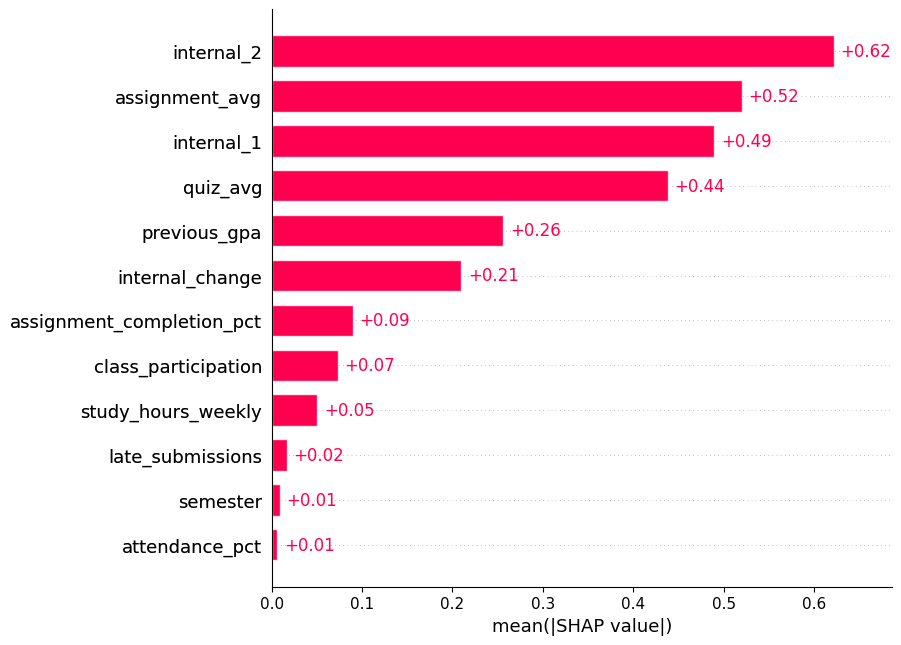

In [31]:
shap.plots.bar(
    high_risk_shap,
    max_display=12
)

plt.show()

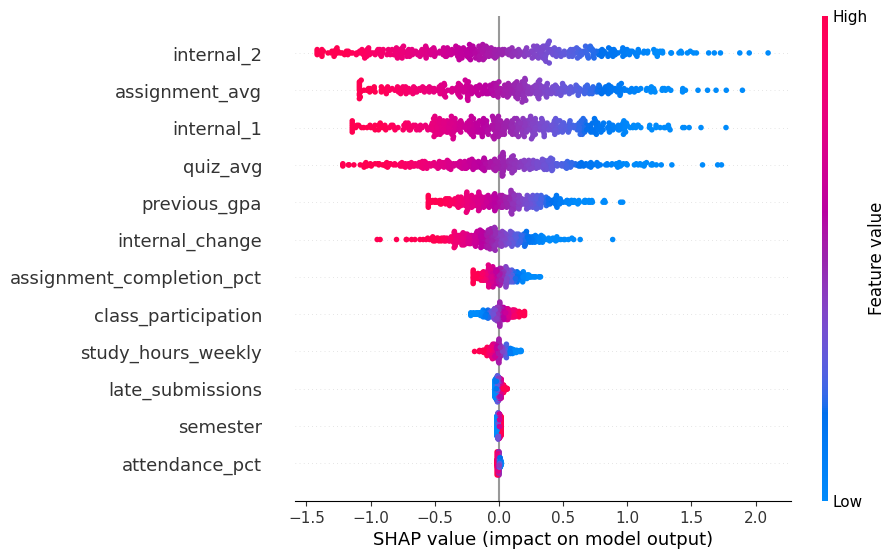

In [32]:
shap.plots.beeswarm(
    high_risk_shap,
    max_display=12
)

plt.show()

In [33]:
high_risk_positions = np.where(
    predictions == "High"
)[0]

print(
    "Number of students predicted High Risk:",
    len(high_risk_positions)
)

print(
    "First 10 High Risk positions:",
    high_risk_positions[:10]
)

Number of students predicted High Risk: 69
First 10 High Risk positions: [10 14 17 23 53 68 77 87 88 92]


In [34]:
student_position = high_risk_positions[0]

student_original_index = X_test.index[
    student_position
]

print(
    "Selected test position:",
    student_position
)

print(
    "Original dataset index:",
    student_original_index
)

print(
    "Actual Risk:",
    y_test.iloc[student_position]
)

print(
    "Predicted Risk:",
    predictions[student_position]
)

Selected test position: 10
Original dataset index: 1331
Actual Risk: Medium
Predicted Risk: High


In [35]:
student_data = X_test.iloc[
    student_position
]

student_data.to_frame(
    name="Student Value"
)

,Student Value
semester,3.00
previous_gpa,5.18
attendance_pct,86.30
internal_1,36.10
internal_2,36.80
assignment_avg,54.60
assignment_completion_pct,73.90
quiz_avg,27.40
study_hours_weekly,13.90
class_participation,7.80


In [36]:
student_scaled = X_test_scaled.iloc[
    [student_position]
]

probabilities = final_model.predict_proba(
    student_scaled
)[0]

probability_df = pd.DataFrame({
    "Risk Level": final_model.classes_,
    "Probability": probabilities
})

probability_df["Probability (%)"] = (
    probability_df["Probability"] * 100
).round(2)

probability_df

,Risk Level,Probability,Probability (%)
0,High,0.663421,66.34
1,Low,0.003890,0.39
2,Medium,0.332689,33.27


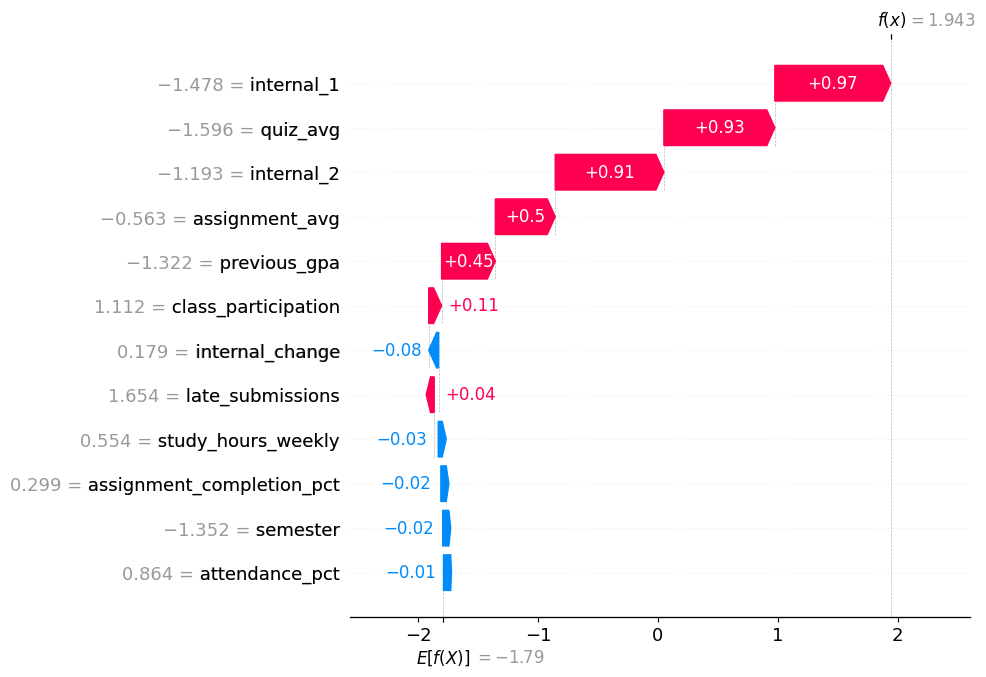

In [37]:
student_high_shap = high_risk_shap[
    student_position
]

shap.plots.waterfall(
    student_high_shap,
    max_display=12
)

In [38]:
student_explanation = pd.DataFrame({
    "Feature": features,
    "Student Value": X_test.iloc[
        student_position
    ].values,
    "SHAP Value": student_high_shap.values
})

student_explanation["Absolute Impact"] = (
    student_explanation["SHAP Value"].abs()
)

student_explanation = (
    student_explanation
    .sort_values(
        "Absolute Impact",
        ascending=False
    )
)

student_explanation

,Feature,Student Value,SHAP Value,Absolute Impact
3,internal_1,36.10,0.967295,0.967295
7,quiz_avg,27.40,0.925946,0.925946
4,internal_2,36.80,0.906893,0.906893
5,assignment_avg,54.60,0.499579,0.499579
1,previous_gpa,5.18,0.448731,0.448731
9,class_participation,7.80,0.107404,0.107404
11,internal_change,0.70,-0.082085,0.082085
10,late_submissions,7.00,0.036260,0.036260
8,study_hours_weekly,13.90,-0.033639,0.033639
6,assignment_completion_pct,73.90,-0.021932,0.021932


In [39]:
risk_factors = student_explanation[
    student_explanation["SHAP Value"] > 0
].copy()

risk_factors = risk_factors.sort_values(
    "SHAP Value",
    ascending=False
)

print("Factors contributing toward High Risk:")

risk_factors.head(5)

Factors contributing toward High Risk:


,Feature,Student Value,SHAP Value,Absolute Impact
3,internal_1,36.10,0.967295,0.967295
7,quiz_avg,27.40,0.925946,0.925946
4,internal_2,36.80,0.906893,0.906893
5,assignment_avg,54.60,0.499579,0.499579
1,previous_gpa,5.18,0.448731,0.448731


In [40]:
protective_factors = student_explanation[
    student_explanation["SHAP Value"] < 0
].copy()

protective_factors = protective_factors.sort_values(
    "SHAP Value"
)

print("Factors reducing High Risk:")

protective_factors.head(5)

Factors reducing High Risk:


,Feature,Student Value,SHAP Value,Absolute Impact
11,internal_change,0.7,-0.082085,0.082085
8,study_hours_weekly,13.9,-0.033639,0.033639
6,assignment_completion_pct,73.9,-0.021932,0.021932
0,semester,3.0,-0.015307,0.015307
2,attendance_pct,86.3,-0.006547,0.006547


In [41]:
top_risk_factors = (
    risk_factors
    .head(5)
    [["Feature", "Student Value", "SHAP Value"]]
    .reset_index(drop=True)
)

print("Top Factors Contributing to High Risk:")
display(top_risk_factors)

Top Factors Contributing to High Risk:


,Feature,Student Value,SHAP Value
0,internal_1,36.10,0.967295
1,quiz_avg,27.40,0.925946
2,internal_2,36.80,0.906893
3,assignment_avg,54.60,0.499579
4,previous_gpa,5.18,0.448731


In [42]:
feature_display_names = {
    "previous_gpa": "Previous GPA",
    "attendance_pct": "Attendance",
    "internal_1": "Internal Assessment 1",
    "internal_2": "Internal Assessment 2",
    "assignment_avg": "Assignment Average",
    "assignment_completion_pct": "Assignment Completion",
    "quiz_avg": "Quiz Average",
    "study_hours_weekly": "Weekly Study Hours",
    "class_participation": "Class Participation",
    "late_submissions": "Late Submissions",
    "internal_change": "Internal Performance Change",
    "semester": "Semester"
}

top_risk_factors["Readable Feature"] = (
    top_risk_factors["Feature"]
    .map(feature_display_names)
)

display(
    top_risk_factors[
        [
            "Readable Feature",
            "Student Value",
            "SHAP Value"
        ]
    ]
)

,Readable Feature,Student Value,SHAP Value
0,Internal Assessment 1,36.10,0.967295
1,Quiz Average,27.40,0.925946
2,Internal Assessment 2,36.80,0.906893
3,Assignment Average,54.60,0.499579
4,Previous GPA,5.18,0.448731


In [43]:
print("ACADEMIC RISK EXPLANATION")
print("-" * 45)

print("Predicted Risk Level: High")

print("\nMajor contributing factors:")

for _, row in top_risk_factors.iterrows():

    feature_name = row["Readable Feature"]
    value = row["Student Value"]

    print(
        f"- {feature_name}: {value:.2f}"
    )

ACADEMIC RISK EXPLANATION
---------------------------------------------
Predicted Risk Level: High

Major contributing factors:
- Internal Assessment 1: 36.10
- Quiz Average: 27.40
- Internal Assessment 2: 36.80
- Assignment Average: 54.60
- Previous GPA: 5.18


## SHAP Explainability Summary

SHAP analysis was used to interpret the predictions generated by the selected
Logistic Regression model.

Global SHAP analysis showed that Internal Assessment 2, assignment average,
Internal Assessment 1, quiz average, and previous GPA were among the most
influential features affecting High Risk predictions in the current synthetic
dataset.

Attendance had relatively low global influence on the selected model's High
Risk output. This demonstrates that the prediction model does not rely on
attendance alone and instead considers multiple academic and engagement
indicators.

Local SHAP analysis was also performed for an individual student predicted as
High Risk. The explanation identified the specific academic factors that
increased the student's High Risk prediction, including weak internal
assessment performance, low quiz performance, assignment performance, and
previous academic performance.

These explanations provide the foundation for the Academic Intervention Engine,
which can map identified risk factors to personalized improvement
recommendations.

### Limitation

The SHAP explanations describe the behaviour of the machine learning model
trained on the synthetic dataset. They should not be interpreted as causal
relationships or as conclusions about real student populations. Validation
using real institutional data would be required before practical deployment.